In [1]:
import numpy as np
import pandas as pd
import math
import os
import glob
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import clear_output, display
from scipy.signal import find_peaks  # 新增：用于特征提取

# 显式声明模式
%matplotlib inline 

# ==========================================
# 1. 基础路径配置与数据持久化加载
# ==========================================
# base_path = r'D:\code\data\green'
base_path = "D:/Workspace/5_Data/bupt_ring_selftest/wsx/报告/green/parsed_results/"
search_pattern = os.path.join(base_path, '202*.csv')
file_list = sorted(glob.glob(search_pattern))

if not file_list:
    print("❌ 未找到数据文件，请检查路径！")
else:
    print("⏳ 正在读取并拼接原始 CSV 数据，请稍候...")
    df_list = [pd.read_csv(f) for f in file_list]
    df = pd.concat(df_list, ignore_index=True)
    
    # 清理多余列并处理缺失值
    columns_to_drop = ['clean_green1', 'butter_green1']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')
    df['green1'] = df['green1'].ffill().fillna(0)  

    # 反转信号极性
    INVERT_POLARITY = True
    polarity_multiplier = -1.0 if INVERT_POLARITY else 1.0
    raw_signal = df['green1'].values * polarity_multiplier
    
    total_points = len(raw_signal)
    fs = 100  # 采样率 100Hz
    print(f"✅ 数据加载就绪！总行数: {total_points}，总时长: {total_points/fs:.1f} 秒")

df["Datetime"] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d-%m-%Y %H:%M:%S')
df.drop(['Date', 'Time', 'Duration', 'ir1', 'ir2'], axis=1, inplace=True)

⏳ 正在读取并拼接原始 CSV 数据，请稍候...
✅ 数据加载就绪！总行数: 8262961，总时长: 82629.6 秒


In [2]:
df

,green1,green2,accX,accY,accZ,Datetime
0,8715406.0,8502910.0,-200.0,-2076.0,156.0,2026-06-10 11:31:23
1,8716251.0,8503157.0,-184.0,-2064.0,156.0,2026-06-10 11:31:23
2,8715944.0,8503201.0,-100.0,-2004.0,136.0,2026-06-10 11:31:23
3,8715814.0,8503174.0,-84.0,-1988.0,148.0,2026-06-10 11:31:23
4,8715142.0,8503446.0,-84.0,-1984.0,140.0,2026-06-10 11:31:23
...,...,...,...,...,...,...
8262956,10356528.0,11099156.0,-744.0,-96.0,2328.0,2026-06-11 17:09:08
8262957,10356826.0,11099703.0,-744.0,-96.0,2328.0,2026-06-11 17:09:08
8262958,10357424.0,11100410.0,-744.0,-96.0,2328.0,2026-06-11 17:09:08
8262959,10357696.0,11101058.0,-744.0,-96.0,2328.0,2026-06-11 17:09:08


In [3]:
df['motion'] = np.linalg.norm(df[['accX', 'accY', 'accZ']], axis=1)

In [4]:
df

,green1,green2,accX,accY,accZ,Datetime,motion
0,8715406.0,8502910.0,-200.0,-2076.0,156.0,2026-06-10 11:31:23,2091.437783
1,8716251.0,8503157.0,-184.0,-2064.0,156.0,2026-06-10 11:31:23,2078.049085
2,8715944.0,8503201.0,-100.0,-2004.0,136.0,2026-06-10 11:31:23,2011.097213
3,8715814.0,8503174.0,-84.0,-1988.0,148.0,2026-06-10 11:31:23,1995.270408
4,8715142.0,8503446.0,-84.0,-1984.0,140.0,2026-06-10 11:31:23,1990.706407
...,...,...,...,...,...,...,...
8262956,10356528.0,11099156.0,-744.0,-96.0,2328.0,2026-06-11 17:09:08,2445.881436
8262957,10356826.0,11099703.0,-744.0,-96.0,2328.0,2026-06-11 17:09:08,2445.881436
8262958,10357424.0,11100410.0,-744.0,-96.0,2328.0,2026-06-11 17:09:08,2445.881436
8262959,10357696.0,11101058.0,-744.0,-96.0,2328.0,2026-06-11 17:09:08,2445.881436


<Axes: >

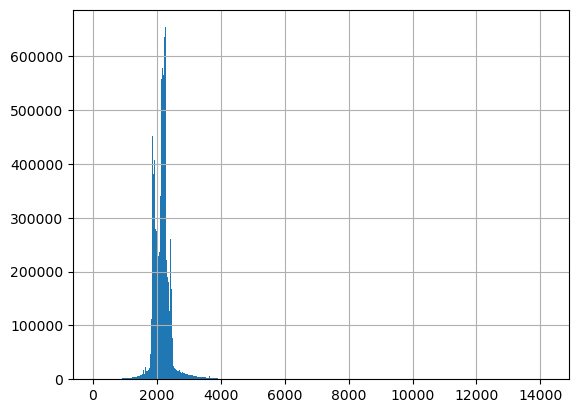

In [5]:
df.motion.hist(bins=500)

In [6]:
df["motion"] = df["motion"].fillna(0)

In [7]:
x = pd.Series(df.motion.to_numpy().astype(int))
x

0          2091
1          2078
2          2011
3          1995
4          1990
           ... 
8262956    2445
8262957    2445
8262958    2445
8262959    2445
8262960    2445
Length: 8262961, dtype: int64

In [8]:
x_d = x.groupby(x.index // 100).mean().astype(int)
x_d

0        2040
1        2037
2        2291
3        2276
4        2222
         ... 
82625    2445
82626    2445
82627    2445
82628    2445
82629    2445
Length: 82630, dtype: int64

In [9]:
x_d.value_counts()

1875    3339
1884    2142
2267    2037
1930    1750
2241    1719
        ... 
1629       1
1763       1
3825       1
3175       1
3231       1
Name: count, Length: 1827, dtype: int64

In [10]:
y = (x_d - 2048).abs()
y

0          8
1         11
2        243
3        228
4        174
        ... 
82625    397
82626    397
82627    397
82628    397
82629    397
Length: 82630, dtype: int64

<Axes: >

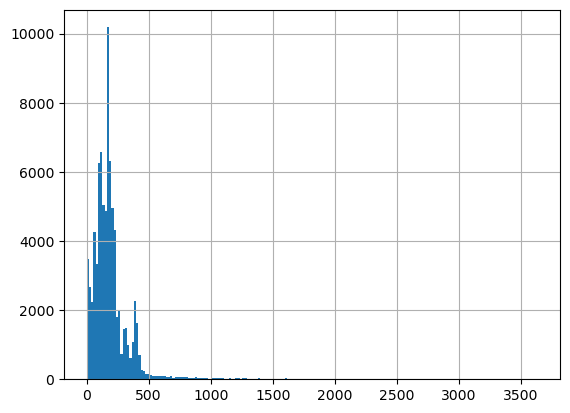

In [11]:
y.hist(bins=200)

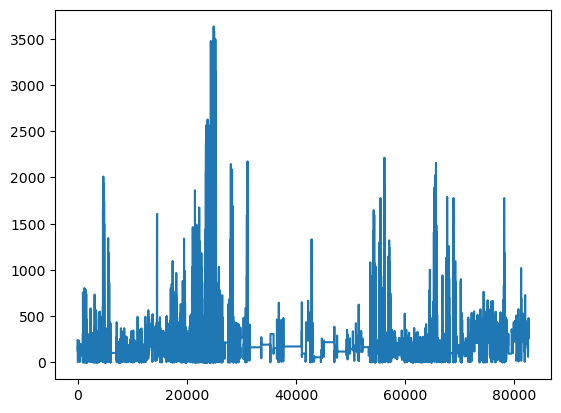

In [12]:
plt.plot(y)

In [13]:
df["motion"] = df["motion"].fillna(0)
x = pd.Series(df.motion.to_numpy().astype(int))
x_d = x.groupby(x.index // 100).mean().astype(int)
y = (x_d - 2048).abs()
y



0          8
1         11
2        243
3        228
4        174
        ... 
82625    397
82626    397
82627    397
82628    397
82629    397
Length: 82630, dtype: int64

# 体动计算方式

<Axes: >

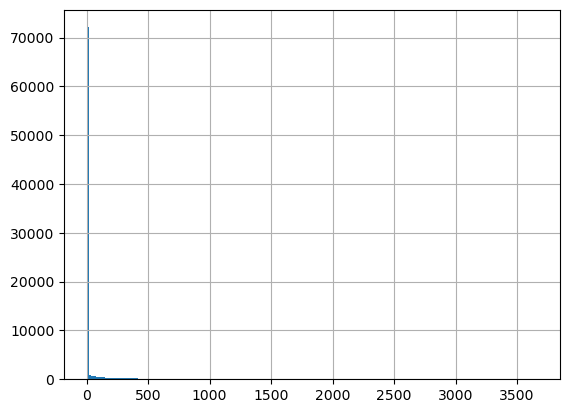

In [22]:
import pandas as pd
import numpy as np

# 1. 安全处理空值：用前向填充(维持上一个状态) 或者 直接填 2048(代表静止)，绝对不能填 0
x = pd.Series(df["motion"].fillna(2048).to_numpy().astype(int))

# 2. 提取瞬时运动强度 (先整流)
# 计算每个采样点偏离重力基线的绝对值
inst_motion = (x - 2048).abs()

# 3. 噪声阈值截断 (消灭底噪和静态姿态偏移引起的假峰)
# 如果 100 以内的偏移属于静止底噪，强制归零
threshold = 800

inst_motion_clean = inst_motion.where(inst_motion > threshold, 0)

# 4. 窗口聚合 (降采样)
# 对清理后的绝对运动量求均值
y = inst_motion_clean.groupby(inst_motion_clean.index // 100).mean()

# 查看分布
y.hist(bins=200)

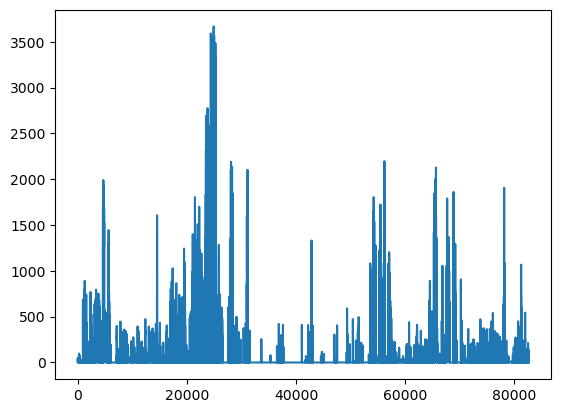

In [23]:
plt.plot(y)